<a href="https://colab.research.google.com/github/brucenguyen0302-code/warehouse-pick-optimiser/blob/main/notebooks/Nguyen_LeBinh_AT1_1_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AT1 Example I - Warehouse Pick-Path Optimisation

**Le Binh Nguyen (26205599)** - 42172 Introduction to AI

This notebook solves a route optimisation problem in a real warehouse. A picker must
collect every item in a picking wave from shelves spread across the warehouse floor and
return to the packing station. The goal is to find the order of stops that gives the
shortest total walking distance.

Two AI techniques are compared: **Simulated Annealing** and **Genetic Algorithm**. A\* search is used to measure true walking distance around the racking.

**Data:** de Assis, R. F. et al. *Order Picking Dataset from a Warehouse of a Footwear
Manufacturing Company.* Mendeley Data, V1. https://doi.org/10.17632/pf2w725pw3.1

## 1. Setup and data

### 1.1 Connect to the data

This cell
mounts Drive, then searches it for `Storage_Location.csv` and uses whichever folder
contains that file as the data directory. Searching instead of hardcoding a path means the
notebook still works if the folder is moved or renamed. If the file is not found it raises
an error immediately, so a missing file is caught here rather than causing a confusing
failure several cells later.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import os, glob

NEEDED = ['Storage_Location.csv', 'Support_Points_Navigation.csv',
          'Picking_Wave.csv', 'Customer_Order.csv', 'Product.csv']

hits = glob.glob('/content/gdrive/MyDrive/**/Storage_Location.csv', recursive=True)
if not hits:
    raise FileNotFoundError(
        'Storage_Location.csv not found anywhere in your Drive. '
        'Upload the five CSVs to a folder in Google Drive.')

DATA_DIR = os.path.dirname(hits[0])
print(f'DATA_DIR = {DATA_DIR}\n')

for name in NEEDED:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        print(f'  found  {os.path.getsize(path)/1e6:7.2f} MB  {name}')
    else:
        print(f'  MISSING              {name}')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
DATA_DIR = /content/gdrive/MyDrive/IntroToAI/AT1_I/data

  found     0.07 MB  Storage_Location.csv
  found     0.00 MB  Support_Points_Navigation.csv
  found     9.68 MB  Picking_Wave.csv
  found     9.46 MB  Customer_Order.csv
  found     0.00 MB  Product.csv


### 1.2 Load the warehouse layout

Two files describe the building. `Storage_Location.csv` gives the coordinates of all 2,292
storage locations. `Support_Points_Navigation.csv` gives the navigation waypoints the
picker travels along.

The navigation file uses carriage-return line endings rather than newlines, so it appears
as one continuous line in most tools. A regular expression is used to pull out each
coordinate and its label, which works regardless of how the lines are terminated. Both
files begin with an invisible byte-order mark, which is why `encoding='utf-8-sig'` is
needed - without it the first column name is corrupted.

The output shows the structure of the building: 17 horizontal aisles and 3 vertical
corridors.

In [2]:
import re
import numpy as np
import pandas as pd

storage = pd.read_csv(os.path.join(DATA_DIR, 'Storage_Location.csv'))
storage['location'] = storage['originalLocation'].astype(str).str.strip()

nav_text = open(os.path.join(DATA_DIR, 'Support_Points_Navigation.csv'),
                encoding='utf-8-sig').read()
nav = pd.DataFrame(
    re.findall(r'\(([-\d.]+),\s*([-\d.]+),\s*([-\d.]+)\);([A-Z]+)-(\d+)', nav_text),
    columns=['x', 'y', 'z', 'rail', 'index']).astype({'x': float, 'y': float})

AISLE_Y    = np.array(sorted(nav['y'].unique()))
CORRIDOR_X = np.array(sorted(nav['x'].unique()))

print(f'storage locations   : {len(storage):,}')
print(f'aisles (horizontal) : {len(AISLE_Y)}  at y = {AISLE_Y.astype(int).tolist()}')
print(f'corridors (vertical): {len(CORRIDOR_X)}  at x = {CORRIDOR_X.astype(int).tolist()}')

storage locations   : 2,292
aisles (horizontal) : 17  at y = [-29, 61, 151, 241, 331, 421, 511, 631, 751, 841, 931, 1021, 1111, 1201, 1291, 1381, 1471]
corridors (vertical): 3  at x = [66, 403, 686]


### 1.3 Convert storage locations into walking positions

Stock sits inside the racking, but the picker stands in the aisle next to it. Each storage
location is therefore mapped to the position the picker actually walks to: the same x
coordinate, at the nearest aisle.

This matters because many locations share one standing position. The four rack levels at a
single spot, and the rows on either side of an aisle, all collapse to the same stop. The
2,292 storage locations reduce to 466 distinct floor positions, so a wave listing 20 items
may require only 14 places to walk to.

**Assumption:** vertical level (z) is ignored and the problem is treated in two dimensions,
because reaching a higher shelf affects picking time but not walking distance.

In [3]:
nearest = np.abs(storage['y'].values[:, None] - AISLE_Y).argmin(axis=1)
storage['face_x'] = storage['x']
storage['face_y'] = AISLE_Y[nearest]
storage['face']   = list(zip(storage['face_x'], storage['face_y']))

print(f'{len(storage):,} storage locations collapse to '
      f'{storage["face"].nunique():,} distinct floor stops')
print('reach-in distance from aisle to rack:',
      sorted({int(d) for d in abs(storage['y'] - storage['face_y'])}), 'units')

2,292 storage locations collapse to 466 distinct floor stops
reach-in distance from aisle to rack: [27, 29, 31, 57, 59] units


### 1.4 Load and clean the picking waves

This loads all 215,192 pick lines and attaches a floor position to each one.

11% of pick lines refer to locations that do not appear in the coordinate file. These are
only 22 distinct codes, almost all `RC-01`, and they belong to a zone of the warehouse for
which the dataset authors did not publish coordinates. Those lines are removed because
their position is unknown and they cannot be routed.

The cell prints how many lines are dropped and which codes they are, so the exclusion is
visible and can be justified rather than happening silently.

In [4]:
waves_raw = pd.read_csv(os.path.join(DATA_DIR, 'Picking_Wave.csv'),
                        sep=';', encoding='utf-8-sig')
waves_raw.columns = [c.strip() for c in waves_raw.columns]
waves_raw['location'] = waves_raw['locations'].astype(str).str.strip()

face_of = dict(zip(storage['location'], storage['face']))
waves_raw['face'] = waves_raw['location'].map(face_of)

unmapped = waves_raw['face'].isna()
print(f'pick lines total   : {len(waves_raw):,}')
print(f'unmapped locations : {unmapped.sum():,} ({unmapped.mean():.1%}) '
      f'across {waves_raw.loc[unmapped, "location"].nunique()} distinct codes')
print('  most common      :',
      waves_raw.loc[unmapped, 'location'].value_counts().head(3).to_dict())

waves_clean = waves_raw[~unmapped].copy()

pick lines total   : 215,192
unmapped locations : 23,609 (11.0%) across 22 distinct codes
  most common      : {'RC-01': 22979, 'RC-04': 361, 'RC-05': 100}


### 1.5 Build routable waves and split by date

Individual customer orders in this dataset average fewer than two distinct products, so
there is no meaningful route to optimise at order level. This is exactly why the company
groups orders into picking waves before sending a picker out, and the wave is therefore the
unit being optimised.

Waves with fewer than 8 stops are excluded, because with so few stops the problem can be
solved by inspection and does not need a metaheuristic.

Each wave is dated from its earliest customer order, and the waves are split
chronologically at 1 July 2023. Earlier waves are used for tuning parameters and later
waves are held back entirely. This gives a genuine test on future data, rather than a
random split which would let information from the test period leak into tuning.

In [5]:
orders = pd.read_csv(os.path.join(DATA_DIR, 'Customer_Order.csv'),
                     sep=';', encoding='utf-8-sig')
orders.columns = [c.strip() for c in orders.columns]
orders['date'] = pd.to_datetime(orders['creationDate'],
                                format='%d/%m/%Y %H:%M', errors='coerce')
wave_date = orders.groupby('waveNumber')['date'].min()

MIN_STOPS  = 8
SPLIT_DATE = pd.Timestamp('2023-07-01')

stops = waves_clean.groupby('waveNumber')['face'].apply(lambda s: list(dict.fromkeys(s)))
waves = pd.DataFrame({'stops': stops, 'n_stops': stops.apply(len)})
waves['date']  = wave_date.reindex(waves.index)
waves = waves[(waves['n_stops'] >= MIN_STOPS) & waves['date'].notna()]
waves['split'] = np.where(waves['date'] < SPLIT_DATE, 'tune', 'test')

print(f'routable waves (>= {MIN_STOPS} stops): {len(waves):,}')
print(f'  stops per wave : mean {waves.n_stops.mean():.1f}  '
      f'median {waves.n_stops.median():.0f}  max {waves.n_stops.max()}')
print(f'  date range     : {waves.date.min().date()} to {waves.date.max().date()}')
print(waves['split'].value_counts().to_string())

routable waves (>= 8 stops): 5,858
  stops per wave : mean 13.8  median 14  max 24
  date range     : 2023-01-05 to 2023-10-19
split
tune    3633
test    2225


## 2. Navigation: measuring real walking distance

### 2.1 Build the aisle network

The picker cannot walk in straight lines because racking is in the way. Movement is
restricted to 17 horizontal aisles and 3 vertical corridors, and the corridors are the only
places where the picker can change aisle.

This cell builds that movement network as a weighted graph. Nodes are positions where the
picker can stand, and edges are the aisle and corridor segments connecting them, weighted
by their length. The packing station is placed at corridor point CC-08, which is where the
dataset authors mark it on their layout drawing.

In [6]:
import heapq, itertools, random

faces = sorted(set(storage['face']))
rail_levels = {x: sorted(nav.loc[nav['x'] == x, 'y'].unique()) for x in CORRIDOR_X}

nodes_on_aisle = {y: set() for y in AISLE_Y}
for x, y in faces:
    nodes_on_aisle[y].add(x)
for x, ys in rail_levels.items():
    for y in ys:
        nodes_on_aisle[y].add(x)

graph = {}
def connect(a, b, weight):
    graph.setdefault(a, []).append((b, weight))
    graph.setdefault(b, []).append((a, weight))

for y, xs in nodes_on_aisle.items():              # walk along an aisle
    xs = sorted(xs)
    for x1, x2 in zip(xs, xs[1:]):
        connect((x1, y), (x2, y), x2 - x1)

for x, ys in rail_levels.items():                 # change aisle at a corridor
    for y1, y2 in zip(ys, ys[1:]):
        connect((x, y1), (x, y2), y2 - y1)

DEPOT = (403.0, 631.0)   # corridor point CC-08, per the dataset's layout figure

print(f'network : {len(graph):,} nodes, {sum(len(v) for v in graph.values())//2:,} edges')
print(f'depot   : {DEPOT}  present in network: {DEPOT in graph}')

network : 500 nodes, 524 edges
depot   : (403.0, 631.0)  present in network: True


### 2.2 A\* search

A\* finds the shortest walking distance between two positions in the network. It uses
Manhattan distance as its heuristic, which is admissible here because all movement is along
horizontal or vertical segments, so the straight-line estimate can never exceed the true
distance. Admissibility is what guarantees A\* returns an optimal path.

Dijkstra's algorithm is also implemented. It is not a competing technique - it is an
independently written reference used in the next cell to check that A\* is correct.

In [7]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def astar(start, goal):
    """Shortest walking distance between two positions.

    Returns (distance, number of nodes expanded).
    """
    if start == goal:
        return 0.0, 0

    counter  = itertools.count()
    frontier = [(manhattan(start, goal), 0.0, next(counter), start)]
    best_g   = {start: 0.0}
    closed   = set()

    while frontier:
        _, g, _, node = heapq.heappop(frontier)
        if node in closed:
            continue
        closed.add(node)
        if node == goal:
            return g, len(closed)
        for nxt, weight in graph[node]:
            tentative = g + weight
            if tentative < best_g.get(nxt, float('inf')):
                best_g[nxt] = tentative
                heapq.heappush(frontier, (tentative + manhattan(nxt, goal),
                                          tentative, next(counter), nxt))
    return float('inf'), len(closed)


def dijkstra_from(start):
    """Exact distance from start to every node. Reference for checking A*."""
    dist, frontier, closed = {start: 0.0}, [(0.0, start)], set()
    while frontier:
        d, node = heapq.heappop(frontier)
        if node in closed:
            continue
        closed.add(node)
        for nxt, weight in graph[node]:
            if d + weight < dist.get(nxt, float('inf')):
                dist[nxt] = d + weight
                heapq.heappush(frontier, (dist[nxt], nxt))
    return dist

### 2.3 Verify A\*, then precompute all distances

A\* is checked against Dijkstra on 300 random pairs of positions. The two must agree
exactly, and the heuristic is confirmed admissible on every pair. Because the two
algorithms were written separately, a bug would have to appear in both to go unnoticed.

A distance matrix is then built once for all 466 positions, so the optimisation stage can
look distances up instead of searching repeatedly. A single simulated annealing run needs
hundreds of thousands of distance lookups; re-running A\* for each one would take minutes
instead of milliseconds.

The matrix is checked for symmetry, a zero diagonal and finite values. An earlier version
of this code passed visual inspection while being silently wrong in one row, which is why
these assertions are here.

In [8]:
rng   = random.Random(0)
pairs = [(rng.choice(faces), rng.choice(faces)) for _ in range(300)]

fields, mismatch, expanded = {}, 0, []
for s, g in pairs:
    if s not in fields:
        fields[s] = dijkstra_from(s)
    cost, n = astar(s, g)
    expanded.append(n)
    if abs(cost - fields[s][g]) > 1e-9:
        mismatch += 1

print(f'A* vs Dijkstra on 300 pairs : {300 - mismatch} identical, {mismatch} mismatched')
print(f'heuristic admissible        : '
      f'{all(manhattan(s, g) <= astar(s, g)[0] + 1e-9 for s, g in pairs)}')
print(f'A* nodes expanded           : mean {np.mean(expanded):.0f} of {len(graph)}')
ratio = [astar(s, g)[0] / max(manhattan(s, g), 1) for s, g in pairs if s != g]
print(f'walking vs straight line    : mean {np.mean(ratio):.2f}x, max {np.max(ratio):.2f}x')

POINTS = [DEPOT] + [f for f in faces if f != DEPOT]
INDEX  = {p: i for i, p in enumerate(POINTS)}
assert len(INDEX) == len(POINTS), 'duplicate point in POINTS'

DIST = np.zeros((len(POINTS), len(POINTS)))
for p in POINTS:
    field = dijkstra_from(p)
    DIST[INDEX[p]] = [field.get(q, np.inf) for q in POINTS]

print(f'\ndistance matrix {DIST.shape[0]}x{DIST.shape[1]}')
print(f'  symmetric     : {np.allclose(DIST, DIST.T)}')
print(f'  zero diagonal : {np.allclose(np.diag(DIST), 0)}')
print(f'  all finite    : {np.isfinite(DIST).all()}')
print(f'  longest walk  : {DIST.max():.0f} units = {DIST.max()/10:.0f} m')

A* vs Dijkstra on 300 pairs : 300 identical, 0 mismatched
heuristic admissible        : True
A* nodes expanded           : mean 54 of 500
walking vs straight line    : mean 1.17x, max 3.55x

distance matrix 466x466
  symmetric     : True
  zero diagonal : True
  all finite    : True
  longest walk  : 2080 units = 208 m


## 3. Objective function and baselines

### 3.1 Defining the objective

A route is a sequence of stops. Its cost is the total walking distance from the packing
station, through every stop in that order, and back to the station. Distances come from the
matrix built in Section 2, so evaluating a route is a handful of array lookups.

The objective is wrapped in a class that counts how many times it is called. Simulated
annealing and the genetic algorithm evaluate different numbers of routes per iteration, so
comparing them fairly requires giving them the same number of objective evaluations rather
than the same number of iterations. The counter is what makes that possible.

In [9]:
def route_length(order):
    """Total walking distance: depot -> stops in the given order -> depot."""
    total = DIST[0, order[0]]
    for a, b in zip(order, order[1:]):
        total += DIST[a, b]
    return total + DIST[order[-1], 0]


def is_valid_route(order, stops):
    """A route must visit every stop exactly once and nothing else."""
    return len(order) == len(stops) and set(order) == set(stops)


class CountedObjective:
    """Wraps the objective and counts calls, so SA and GA can be given equal budgets."""
    def __init__(self, fn):
        self.fn, self.calls = fn, 0
    def __call__(self, order):
        self.calls += 1
        return self.fn(order)
    def reset(self):
        self.calls = 0


waves['route'] = waves.stops.apply(lambda s: [INDEX[p] for p in s])

example = waves.iloc[0]
print(f'example wave {example.name}: {example.n_stops} stops')
print(f'  listed order length : {route_length(example.route):,.0f} units')
print(f'  valid route         : {is_valid_route(example.route, example.route)}')

example wave 33168: 21 stops
  listed order length : 6,872 units
  valid route         : True


### 3.2 Three reference points

Three baselines are needed before any result can be interpreted.

**Random order** shows what happens with no organisation at all. It is a weak baseline and
beating it proves very little, but it is included because several published studies use it,
and comparing it with the next baseline shows how much that choice inflates results.

**Listed order** is the sequence the picks appear in within the dataset. Checking 300 waves
confirms this is not simply sorted by product or by location, so it reflects the order the
company's own system produced. This is the honest baseline: it represents what is being
done today, and it is what any improvement must be measured against.

**Nearest neighbour** repeatedly walks to the closest unvisited stop. It is a greedy
heuristic, not a metaheuristic, and it shows how much of the available improvement can be
captured by a simple rule.

In [10]:
def random_order(stops, seed):
    order = list(stops)
    random.Random(seed).shuffle(order)
    return order


def nearest_neighbour(stops):
    """Repeatedly walk to whichever unvisited stop is closest."""
    unvisited, current, route = set(stops), 0, []
    while unvisited:
        nxt = min(unvisited, key=lambda j: DIST[current, j])
        route.append(nxt)
        unvisited.discard(nxt)
        current = nxt
    return route


tune = waves[waves.split == 'tune']

baselines = pd.DataFrame(index=tune.index)
baselines['listed'] = tune.route.apply(route_length)
baselines['random'] = tune.route.apply(
    lambda r: np.mean([route_length(random_order(r, s)) for s in range(5)]))
baselines['nearest_neighbour'] = tune.route.apply(
    lambda r: route_length(nearest_neighbour(r)))

print(f'mean route length over {len(tune):,} tuning waves')
for c in ['random', 'listed', 'nearest_neighbour']:
    print(f'  {c:18s}: {baselines[c].mean():8,.0f} units')

mean route length over 3,633 tuning waves
  random            :    6,796 units
  listed            :    3,787 units
  nearest_neighbour :    3,318 units


### 3.3 The true optimum

For waves with few enough stops the shortest possible route can be computed exactly using
the Held-Karp dynamic programming algorithm. Its cost grows as O(n^2 * 2^n), so it is only
practical up to about 12 stops, but that is enough to establish ground truth on part of the
data.

This is what makes the results interpretable. Without it, we could only say one method beats
another. With it, we can say how far each method is from the best route that exists.

In [11]:
def held_karp(stops):
    """Exact shortest route by dynamic programming. Feasible up to about 12 stops."""
    n = len(stops)
    dp = {(1 << i, i): (DIST[0, stops[i]], -1) for i in range(n)}
    for size in range(2, n + 1):
        for subset in itertools.combinations(range(n), size):
            mask = sum(1 << i for i in subset)
            for last in subset:
                prev = mask ^ (1 << last)
                dp[(mask, last)] = min(
                    (dp[(prev, k)][0] + DIST[stops[k], stops[last]], k)
                    for k in subset if k != last)
    full = (1 << n) - 1
    cost, last = min((dp[(full, i)][0] + DIST[stops[i], 0], i) for i in range(n))
    order, mask = [], full
    while last != -1:
        order.append(stops[last])
        nxt = dp[(mask, last)][1]
        mask ^= 1 << last
        last = nxt
    return order[::-1], cost


EXACT_MAX_STOPS, EXACT_SAMPLE = 11, 150
small = tune[tune.n_stops <= EXACT_MAX_STOPS].head(EXACT_SAMPLE)

optimum = small.route.apply(lambda r: held_karp(r)[1])

print(f'exact optimum on {len(small)} waves of <= {EXACT_MAX_STOPS} stops')
print('gap above the true optimum:')
for c in ['random', 'listed', 'nearest_neighbour']:
    print(f'  {c:18s}: {(baselines.loc[small.index, c] / optimum - 1).mean():6.1%}')

exact optimum on 150 waves of <= 11 stops
gap above the true optimum:
  random            :  76.0%
  listed            :  17.1%
  nearest_neighbour :   4.6%


### 3.4 Hill climbing

Hill climbing is the third local search algorithm from Lab 3. It starts from a random route,
repeatedly swaps two stops, and keeps a swap only when it shortens the route. Because it
never accepts a worse route it becomes trapped in local optima, so it is restarted from
several random starting points and the best result kept.

It is included as a reference point rather than as one of the compared techniques. It shows
what plain local search achieves, which is the bar simulated annealing must clear to justify
its extra machinery.

In [12]:
def hill_climbing(stops, objective, iterations=1500, restarts=20, seed=0):
    """Lab 3 hill climbing: swap two stops, keep the change only if it improves."""
    rng = random.Random(seed)
    best_route, best_cost = None, float('inf')
    for _ in range(restarts):
        current = list(stops)
        rng.shuffle(current)
        current_cost = objective(current)
        for _ in range(iterations):
            i, j = rng.sample(range(len(current)), 2)
            neighbour = current[:]
            neighbour[i], neighbour[j] = neighbour[j], neighbour[i]
            neighbour_cost = objective(neighbour)
            if neighbour_cost < current_cost:
                current, current_cost = neighbour, neighbour_cost
        if current_cost < best_cost:
            best_route, best_cost = current, current_cost
    return best_route, best_cost


HC_SAMPLE = 100
hc_waves = tune.head(HC_SAMPLE)

hc_costs, hc_calls = [], []
for r in hc_waves.route:
    obj = CountedObjective(route_length)
    _, cost = hill_climbing(r, obj, seed=1)
    hc_costs.append(cost)
    hc_calls.append(obj.calls)

hill = pd.Series(hc_costs, index=hc_waves.index)
print(f'hill climbing on {HC_SAMPLE} waves, '
      f'{np.mean(hc_calls):,.0f} objective evaluations each')

hill climbing on 100 waves, 30,020 objective evaluations each


### 3.5 Baseline summary

The table compares all four reference points on the same 100 waves, measured against the
company's existing order.

The important comparison is between the random and listed baselines. The company's own
picking order is already far better than random, which means any study reporting improvement
against a random baseline is measuring mostly the absence of organisation rather than the
value of its algorithm. Measured honestly, against what the warehouse actually does today,
the available improvement is much smaller and much harder to win.

In [13]:
idx = hc_waves.index
ref = baselines.loc[idx, 'listed'].mean()

summary = pd.DataFrame({
    'mean route': [baselines.loc[idx, 'random'].mean(),
                   baselines.loc[idx, 'listed'].mean(),
                   baselines.loc[idx, 'nearest_neighbour'].mean(),
                   hill.mean()],
}, index=['random order', 'listed order (company)', 'nearest neighbour', 'hill climbing'])
summary['vs listed order'] = (summary['mean route'] / ref - 1).map('{:+.1%}'.format)
summary['mean route'] = summary['mean route'].map('{:,.0f}'.format)
print(summary.to_string())

                       mean route vs listed order
random order                7,058          +72.3%
listed order (company)      4,097           +0.0%
nearest neighbour           3,434          -16.2%
hill climbing               3,306          -19.3%


## 4. Simulated Annealing

### 4.1 Neighbourhood functions and cooling schedules

Simulated annealing needs two problem-specific pieces: a way to make a small change to a
route, and a schedule controlling how willing it is to accept a worse route over time.

Two neighbourhood functions are compared. **Swap** exchanges two stops and is the function
used in Lab 3. **2-opt** reverses a whole segment of the route. Reversing a segment removes
crossings in a route, which a single swap usually cannot do without passing through a much
worse intermediate route.

All four cooling schedules from Lab 3 are included: linear, exponential, logarithmic and
fast. Temperature starts high, so early on the search accepts worse routes freely and can
escape a poor region; as temperature falls it becomes increasingly greedy.

In [14]:
import math

def swap_neighbour(route, rng):
    """Lab 3 neighbourhood: exchange two stops."""
    neighbour = route[:]
    i, j = rng.sample(range(len(neighbour)), 2)
    neighbour[i], neighbour[j] = neighbour[j], neighbour[i]
    return neighbour


def two_opt_neighbour(route, rng):
    """Reverse a segment of the route. Removes crossings a swap cannot."""
    neighbour = route[:]
    i, j = sorted(rng.sample(range(len(neighbour)), 2))
    neighbour[i:j + 1] = reversed(neighbour[i:j + 1])
    return neighbour


def linear_cooling(t, T0=1000.0):       return max(0.001, T0 - 0.1 * t)
def exponential_cooling(t, T0=1000.0):  return T0 * (0.995 ** t)
def logarithmic_cooling(t, T0=1000.0):  return T0 / math.log(t + 2)
def fast_cooling(t, T0=1000.0):         return T0 / (t + 1)


COOLING = {'linear': linear_cooling, 'exponential': exponential_cooling,
           'logarithmic': logarithmic_cooling, 'fast': fast_cooling}
NEIGHBOURHOOD = {'swap': swap_neighbour, '2-opt': two_opt_neighbour}

print('neighbourhoods:', list(NEIGHBOURHOOD))
print('cooling schedules:', list(COOLING))

neighbourhoods: ['swap', '2-opt']
cooling schedules: ['linear', 'exponential', 'logarithmic', 'fast']


### 4.2 The algorithm

The search starts from a random route. At each step it generates a neighbouring route and
compares it with the current one. A shorter route is always accepted. A longer route is
accepted with probability exp(-delta / T), so early in the run, while temperature is high,
the search will move to a worse route reasonably often. That willingness to go backwards is
the whole point: it is what lets the search leave a local optimum that hill climbing would
be stuck in.

The best route found is tracked separately from the current route, because the search may
wander away from a good solution and not return to it.

Budget is measured in objective evaluations rather than iterations, so that the genetic
algorithm can later be given exactly the same amount of work.

In [15]:
def simulated_annealing(stops, objective, neighbour, cooling, budget=10000, seed=0):
    rng = random.Random(seed)
    current = list(stops)
    rng.shuffle(current)
    current_cost = objective(current)
    best, best_cost = current[:], current_cost

    for t in range(budget - 1):
        temperature = cooling(t)
        candidate = neighbour(current, rng)
        candidate_cost = objective(candidate)
        delta = candidate_cost - current_cost

        if delta < 0 or (temperature > 0 and rng.random() < math.exp(-delta / temperature)):
            current, current_cost = candidate, candidate_cost
            if current_cost < best_cost:
                best, best_cost = current[:], current_cost

    return best, best_cost


demo = waves.loc[waves[waves.split == 'tune'].index[0]]
obj = CountedObjective(route_length)
route, cost = simulated_annealing(demo.route, obj, two_opt_neighbour,
                                  fast_cooling, 10000, 0)
print(f'demo wave {demo.name} ({demo.n_stops} stops)')
print(f'  listed {route_length(demo.route):,.0f}  ->  SA {cost:,.0f}')
print(f'  {obj.calls:,} evaluations, valid route: {is_valid_route(route, demo.route)}')

demo wave 33168 (21 stops)
  listed 6,872  ->  SA 4,544
  10,000 evaluations, valid route: True


### 4.3 Which neighbourhood and which cooling schedule

Every combination of the two neighbourhoods and four cooling schedules is run on 40 waves
where the exact optimum is known, so the result is a true gap rather than a relative
comparison.

The neighbourhood function is clearly the more important of the two decisions. With the swap
neighbourhood the choice of schedule changes the gap by several percentage points and none of
the schedules reach the optimum reliably. With 2-opt every schedule reaches the optimum.

That second result is a tie, and a tie is not a finding. These waves have at most eleven
stops, which 2-opt solves optimally within the budget whatever the temperature is doing, so
the experiment cannot distinguish between the four schedules — it can only show that they are
all sufficient here. Choosing one of them on this evidence would be choosing arbitrarily. The
next cell repeats the question on waves large enough to answer it.

In [16]:
STUDY_N, STUDY_BUDGET = 40, 10000
study = small.head(STUDY_N)
study_opt = optimum.loc[study.index]

rows = []
for cooling_name, cooling in COOLING.items():
    row = {}
    for nb_name, nb in NEIGHBOURHOOD.items():
        gaps = [simulated_annealing(r, CountedObjective(route_length), nb, cooling,
                                    STUDY_BUDGET, 1)[1] / o - 1
                for r, o in zip(study.route, study_opt)]
        row[nb_name] = np.mean(gaps)
    rows.append(row)

tuning = pd.DataFrame(rows, index=list(COOLING)).map('{:.2%}'.format)
print(f'mean gap above the exact optimum '
      f'({STUDY_N} waves, budget {STUDY_BUDGET:,} evaluations)')
print(tuning.to_string())

mean gap above the exact optimum (40 waves, budget 10,000 evaluations)
              swap  2-opt
linear       0.16%  0.00%
exponential  2.36%  0.00%
logarithmic  0.15%  0.00%
fast         4.57%  0.06%


### 4.4 The same question on waves large enough to answer it

The schedules are compared again on the twelve largest tuning waves, where the optimum is out
of reach and the search actually has to work.

Measuring this naively would mean re-running each schedule once per budget. It is cheaper and
more accurate to record the best route found so far at every evaluation during a single run,
which gives the result for every budget at once from the same run. `TracedObjective` does
this by wrapping the objective exactly as `CountedObjective` does, so both are measured with
the same instrument.

The result contradicts the tie in 4.3 completely. Linear cooling is worse than the company's
own picking order at every budget below the full 10,000, and only becomes useful in the final
few hundred evaluations. The reason is in the definition: `max(0.001, 1000 - 0.1 * t)` does
not fall to a cold temperature until t reaches 9,999, so for almost the whole run the search
accepts nearly every move it is offered and is effectively wandering at random. Fast cooling
is ahead of every other schedule at every budget and already saves 19% after 500 evaluations.

Fast cooling is therefore used from here on. This is a correction to the configuration, not a
refinement of it, and it is reported rather than quietly applied because the way the mistake
was made is instructive: the tuning experiment in 4.3 was run on instances too easy to
discriminate between the options it was comparing.

In [17]:
class TracedObjective:
    """Counts calls like CountedObjective, and records the best value found so far."""
    def __init__(self, fn):
        self.fn, self.calls, self.best, self.trace = fn, 0, float('inf'), []

    def __call__(self, order):
        self.calls += 1
        value = self.fn(order)
        if value < self.best:
            self.best = value
        self.trace.append(self.best)
        return value


DIAG_N, DIAG_SEEDS = 12, 5
CHECKPOINTS = [500, 1000, 2500, 5000, 10000]

diag = waves[(waves.split == 'tune') & (waves.n_stops >= 18)].head(DIAG_N)
listed_total = diag.route.apply(route_length).sum()

rows = {}
for cooling_name, cooling in COOLING.items():
    curves = []
    for r in diag.route:
        runs = []
        for s in range(DIAG_SEEDS):
            obj = TracedObjective(route_length)
            simulated_annealing(r, obj, two_opt_neighbour, cooling, 10000, s)
            runs.append(obj.trace[:10000])
        curves.append(np.array(runs).mean(0))
    rows[cooling_name] = [1 - sum(c[b - 1] for c in curves) / listed_total
                          for b in CHECKPOINTS]

schedule_table = pd.DataFrame(rows, index=[f'{b:,}' for b in CHECKPOINTS]).T
print(f'saving against the listed order, 2-opt neighbourhood, {DIAG_N} waves '
      f'of {diag.n_stops.min()}-{diag.n_stops.max()} stops, {DIAG_SEEDS} seeds')
print(schedule_table.map('{:.1%}'.format).to_string())

saving against the listed order, 2-opt neighbourhood, 12 waves of 18-23 stops, 5 seeds
                500   1,000   2,500   5,000 10,000
linear       -38.7%  -33.6%  -26.7%  -20.5%  20.6%
exponential   -2.1%   18.6%   22.6%   22.9%  23.0%
logarithmic   -0.9%    6.7%   13.2%   17.0%  19.5%
fast          18.9%   21.9%   22.8%   23.1%  23.1%


### 4.5 How much budget is needed

Small waves are solved optimally by almost any configuration, so budget is chosen on the
largest waves instead. Because simulated annealing is stochastic, each wave is run with
five different random seeds and the spread between the best and worst result is measured.
A configuration that returns a very different answer each time cannot be trusted regardless
of its average. Fast cooling is used throughout, following 4.4.

With 2-opt the spread falls to about 1% by 5,000 evaluations and does not improve with four
times that budget, so 10,000 is used for the main comparison as a safe margin. With the swap
neighbourhood the spread stays above 20% at every budget tested, which shows it is not
converging slowly but failing on problems of this size.

In [18]:
BIG_N = 12
big = waves[(waves.split == 'tune') & (waves.n_stops >= 18)].head(BIG_N)

rows = []
for budget in (1000, 5000, 20000):
    for nb_name, nb in NEIGHBOURHOOD.items():
        spread = []
        for r in big.route:
            runs = [simulated_annealing(r, CountedObjective(route_length), nb,
                                        fast_cooling, budget, s)[1] for s in range(5)]
            spread.append(max(runs) / min(runs) - 1)
        rows.append({'budget': budget, 'neighbourhood': nb_name,
                     'spread across seeds': f'{np.mean(spread):.1%}'})

print(f'run-to-run spread on {BIG_N} large waves (>= 18 stops), 5 seeds each')
print(pd.DataFrame(rows).to_string(index=False))

run-to-run spread on 12 large waves (>= 18 stops), 5 seeds each
 budget neighbourhood spread across seeds
   1000          swap               21.3%
   1000         2-opt                4.8%
   5000          swap               21.0%
   5000         2-opt                1.2%
  20000          swap               22.9%
  20000         2-opt                1.2%


## 5. Genetic Algorithm

### 5.1 Operators

A genetic algorithm keeps a population of routes rather than a single one, and builds each
new generation from the better members of the last.

**Ordered crossover (OX1)** combines two parent routes. A slice of the first parent is
copied directly into the child, and the remaining stops are filled in the order they appear
in the second parent. An ordinary crossover would produce a child visiting some stops twice
and others not at all; OX1 guarantees a valid route by construction.

**Mutation** makes a small random change. Two are compared: swapping two stops, which is
the operator used in Lab 3, and inverting a segment, which is the same move that worked so
much better for simulated annealing.

**Tournament selection** picks three random routes and returns the shortest. Selection
pressure stays moderate, so weaker routes still occasionally reproduce and the population
does not collapse to copies of one solution.

**Elitism** carries the best two routes into the next generation unchanged, so the best
solution found can never be lost.

In [19]:
def ordered_crossover(parent1, parent2, rng):
    """OX1: keep a slice of parent1, fill the rest in parent2's order."""
    size = len(parent1)
    a, b = sorted(rng.sample(range(size), 2))
    child = [None] * size
    child[a:b + 1] = parent1[a:b + 1]
    taken = set(child[a:b + 1])
    fill = (stop for stop in parent2 if stop not in taken)
    for i in range(size):
        if child[i] is None:
            child[i] = next(fill)
    return child


def swap_mutation(route, rng):
    """Lab 3 mutation: exchange two stops."""
    mutated = route[:]
    i, j = rng.sample(range(len(mutated)), 2)
    mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated


def inversion_mutation(route, rng):
    """Reverse a segment, matching the 2-opt move used in simulated annealing."""
    mutated = route[:]
    i, j = sorted(rng.sample(range(len(mutated)), 2))
    mutated[i:j + 1] = reversed(mutated[i:j + 1])
    return mutated


def tournament(population, rng, size=3):
    """Pick `size` routes at random and return the shortest."""
    return min(rng.sample(population, size), key=lambda individual: individual[1])


MUTATION = {'swap': swap_mutation, 'inversion': inversion_mutation}
print('crossover: ordered (OX1)   mutations:', list(MUTATION))

crossover: ordered (OX1)   mutations: ['swap', 'inversion']


### 5.2 The algorithm

Each individual is stored together with its route length, so a route is evaluated once when
it is created and never re-evaluated. This differs from the Lab 3 implementation, which
calls the objective again every time the population is sorted and every time a tournament is
held. That version would consume several times more evaluations per generation than it
appears to, which would make an equal-budget comparison against simulated annealing
impossible to set up honestly.

With caching, the accounting is exact: the initial population costs one evaluation per
individual, and each child costs one. The loop stops the moment the budget is spent, so the
genetic algorithm and simulated annealing perform exactly the same number of objective
evaluations.

In [20]:
def genetic_algorithm(stops, objective, mutation, budget=10000,
                      population_size=100, elite=2, mutation_rate=0.2,
                      tournament_size=3, seed=0):
    rng = random.Random(seed)

    population = []
    for _ in range(population_size):
        individual = list(stops)
        rng.shuffle(individual)
        population.append((individual, objective(individual)))
    used = population_size

    best = min(population, key=lambda i: i[1])

    while used < budget:
        population.sort(key=lambda i: i[1])
        offspring = population[:elite]
        while len(offspring) < population_size and used < budget:
            parent1 = tournament(population, rng, tournament_size)[0]
            parent2 = tournament(population, rng, tournament_size)[0]
            child = ordered_crossover(parent1, parent2, rng)
            if rng.random() < mutation_rate:
                child = mutation(child, rng)
            offspring.append((child, objective(child)))
            used += 1
        population = offspring
        generation_best = min(population, key=lambda i: i[1])
        if generation_best[1] < best[1]:
            best = generation_best

    return best[0], best[1]


demo = waves.loc[waves[waves.split == 'tune'].index[0]]
for name, mut in MUTATION.items():
    obj = CountedObjective(route_length)
    route, cost = genetic_algorithm(demo.route, obj, mut, 10000, seed=0)
    print(f'GA / {name:<10} wave {demo.name}: {cost:>7,.0f}   '
          f'{obj.calls:,} evaluations, valid={is_valid_route(route, demo.route)}')

GA / swap       wave 33168:   5,070   10,000 evaluations, valid=True
GA / inversion  wave 33168:   4,450   10,000 evaluations, valid=True


### 5.3 Population size and mutation operator

Population size trades breadth against depth. For a fixed evaluation budget, a large
population explores many routes but completes few generations; a small population runs many
generations but may converge prematurely on one region.

The same pattern seen with simulated annealing appears again. With inversion mutation the
genetic algorithm reaches the optimum at every population size tested, and population size
barely matters. With Lab 3's swap mutation it never reaches the optimum, and the gap grows
sharply as the population shrinks. The choice of move operator dominates the choice of
population size.

In [21]:
POP_STUDY = small.head(30)
POP_STUDY_OPT = optimum.loc[POP_STUDY.index]

print('GA mean gap above the exact optimum (30 waves, budget 10,000)')
print(f"{'population':>11} {'swap':>9} {'inversion':>11}")
for pop_size in (20, 50, 100, 150):
    row = []
    for mut in (swap_mutation, inversion_mutation):
        gaps = [genetic_algorithm(r, CountedObjective(route_length), mut, 10000,
                                  population_size=pop_size, seed=1)[1] / o - 1
                for r, o in zip(POP_STUDY.route, POP_STUDY_OPT)]
        row.append(np.mean(gaps))
    print(f'{pop_size:>11} {row[0]:>8.2%} {row[1]:>10.2%}')

GA mean gap above the exact optimum (30 waves, budget 10,000)
 population      swap   inversion
         20    3.30%      0.00%
         50    1.52%      0.00%
        100    0.61%      0.00%
        150    0.13%      0.00%


## 6. Comparing the two techniques

### 6.1 Experimental design

Both techniques are stochastic, so a single run of each proves nothing. The comparison is
designed to remove the three ways this kind of study usually goes wrong.

**Equal budget.** Both receive exactly 10,000 objective evaluations. Comparing iterations
or generations instead would be meaningless, because one generation of the genetic
algorithm costs as many evaluations as its population size.

**Multiple seeds.** Each technique runs 30 times per wave with different random seeds, so
the result is a distribution rather than a single number.

**Stratified sample.** 32 waves are chosen across four size bands, eight from each. Sampling
only large or only small waves would hide the fact that the two techniques behave
differently depending on problem size.

Configurations are those selected in Sections 4 and 5: simulated annealing with the 2-opt neighbourhood and fast cooling, and the genetic algorithm with inversion mutation and a population of 100.

In [22]:
from scipy.stats import wilcoxon

BUDGET, SEEDS, PER_BAND = 10000, 30, 8
BANDS = [(8, 11), (12, 15), (16, 19), (20, 24)]

tune = waves[waves.split == 'tune']
selection = pd.concat([tune[tune.n_stops.between(lo, hi)].head(PER_BAND)
                       for lo, hi in BANDS])

print(f'{len(selection)} waves selected, sizes '
      f'{selection.n_stops.min()}-{selection.n_stops.max()}')
print(f'{SEEDS} seeds x 2 techniques x {len(selection)} waves = '
      f'{SEEDS * 2 * len(selection):,} runs')

32 waves selected, sizes 8-23
30 seeds x 2 techniques x 32 waves = 1,920 runs


### 6.2 Running the experiment

Each wave is solved 30 times by each technique. Wall-clock time per run is recorded as well
as route length, because equal evaluation budgets do not imply equal running time.

Results are cached to a CSV in Drive. The experiment takes around five minutes,
and re-running the whole notebook should not have to repeat it. Deleting that file forces a
fresh run.

In [23]:
RESULTS_DIR = os.path.join(os.path.dirname(DATA_DIR), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_FILE = os.path.join(RESULTS_DIR, 'main_comparison_sa-fast.csv')   # <- new name

if os.path.exists(RESULTS_FILE):
    results = pd.read_csv(RESULTS_FILE)
    print(f'loaded cached results from {RESULTS_FILE}')
else:
    import time
    start = time.perf_counter()
    rows = []
    for wave_id, w in selection.iterrows():
        r = w.route

        t = time.perf_counter()
        sa = [simulated_annealing(r, CountedObjective(route_length), two_opt_neighbour,
                                  fast_cooling, BUDGET, s) [1] for s in range(SEEDS)]
        sa_sec = (time.perf_counter() - t) / SEEDS

        t = time.perf_counter()
        ga = [genetic_algorithm(r, CountedObjective(route_length), inversion_mutation,
                                BUDGET, population_size=100, seed=s)[1]
              for s in range(SEEDS)]
        ga_sec = (time.perf_counter() - t) / SEEDS

        rows.append({'wave': wave_id, 'n_stops': w.n_stops,
                     'listed': route_length(r), 'best_known': min(min(sa), min(ga)),
                     'SA_mean': np.mean(sa), 'SA_std': np.std(sa),
                     'SA_best': min(sa), 'SA_sec': sa_sec,
                     'GA_mean': np.mean(ga), 'GA_std': np.std(ga),
                     'GA_best': min(ga), 'GA_sec': ga_sec})

    results = pd.DataFrame(rows)
    results.to_csv(RESULTS_FILE, index=False)
    print(f'experiment finished in {time.perf_counter() - start:.0f}s, '
          f'saved to {RESULTS_FILE}')

results['SA_gap'] = results.SA_mean / results.best_known - 1
results['GA_gap'] = results.GA_mean / results.best_known - 1
results['band'] = pd.cut(results.n_stops, [7, 11, 15, 19, 24],
                         labels=['8-11', '12-15', '16-19', '20-24'])
print(f'{len(results)} waves, {results.n_stops.sum():,} stops total')

loaded cached results from /content/gdrive/MyDrive/IntroToAI/AT1_I/results/main_comparison_sa-fast.csv
32 waves, 500 stops total


### 6.3 Results by wave size

Because the true optimum cannot be computed for the larger waves, results are reported as a
gap above the best route either technique found across all 60 runs of that wave. On the small
waves, where the exact optimum is known from Section 3, this best-known value equals the true
optimum.

Simulated annealing is ahead in every size band, and the margin widens as the waves get
larger. Averaged across all 32 waves its gap is a quarter of the genetic algorithm's.

The standard deviations explain where that margin comes from, and it is not where it might be
expected. Both techniques find the same best route on all 32 waves, so neither is failing to
reach good solutions. What separates them is how often they get there. On the largest waves
simulated annealing varies by about 15 distance units across its 30 seeds and the genetic
algorithm by more than 90. Simulated annealing finds the good route almost every time; the
genetic algorithm finds it sometimes and something worse the rest of the time, and it is the
average over those runs that loses.

In [24]:
by_band = results.groupby('band', observed=True).agg(
    waves=('wave', 'size'),
    SA_gap=('SA_gap', 'mean'), GA_gap=('GA_gap', 'mean'),
    SA_std=('SA_std', 'mean'), GA_std=('GA_std', 'mean'))

print('mean gap above the best route found, by wave size')
print(by_band.assign(
    SA_gap=by_band.SA_gap.map('{:.2%}'.format),
    GA_gap=by_band.GA_gap.map('{:.2%}'.format),
    SA_std=by_band.SA_std.round(1),
    GA_std=by_band.GA_std.round(1)).to_string())

print(f'\noverall gap : SA {results.SA_gap.mean():.2%}   GA {results.GA_gap.mean():.2%}')
print(f'mean route  : SA {results.SA_mean.mean():,.0f}   GA {results.GA_mean.mean():,.0f}'
      f'   (GA {results.GA_mean.mean() / results.SA_mean.mean() - 1:+.2%})')
print(f'identical best route on {(results.SA_best == results.GA_best).sum()} '
      f'of {len(results)} waves')

mean gap above the best route found, by wave size
       waves SA_gap GA_gap  SA_std  GA_std
band                                      
8-11       8  0.00%  0.02%     0.0     3.8
12-15      8  0.50%  0.79%    26.8    64.4
16-19      8  0.51%  1.88%    38.3   106.5
20-24      8  0.22%  2.16%    15.3    91.2

overall gap : SA 0.31%   GA 1.21%
mean route  : SA 3,510   GA 3,544   (GA +0.96%)
identical best route on 32 of 32 waves


### 6.4 Is the difference real?

Simulated annealing produces shorter routes on average, but averages from stochastic
algorithms can differ by chance, so the difference has to be tested rather than asserted.

The Wilcoxon signed-rank test compares the two techniques wave by wave and asks whether the
pattern of differences is larger than randomness would produce. It is used rather than a
t-test because it assumes nothing about the differences being normally distributed, which
with 32 waves of unequal size they are not.

The difference is significant across all 32 waves, and on the 16 largest waves simulated
annealing wins every single one — a test statistic of zero, which is the strongest result
this test can return. Simulated annealing is better here, and the margin is not chance.

In [25]:
stat_all, p_all = wilcoxon(results.SA_mean, results.GA_mean)
large = results[results.n_stops >= 16]
stat_big, p_big = wilcoxon(large.SA_mean, large.GA_mean)

print(f'Wilcoxon signed-rank, all {len(results)} waves     : '
      f'statistic={stat_all:.0f}, p={p_all:.4f}  '
      f'-> {"significant" if p_all < 0.05 else "not significant"}')
print(f'Wilcoxon signed-rank, {len(large)} largest waves : '
      f'statistic={stat_big:.0f}, p={p_big:.4f}  '
      f'-> {"significant" if p_big < 0.05 else "not significant"}')

Wilcoxon signed-rank, all 32 waves     : statistic=12, p=0.0001  -> significant
Wilcoxon signed-rank, 16 largest waves : statistic=0, p=0.0000  -> significant


### 6.5 Cost of the same budget

Equal evaluation budgets make the comparison of route quality fair, but they do not make the
two techniques equally expensive. Every evaluation costs the same, yet the genetic algorithm
does considerably more work around each one: sorting the population every generation, running
two tournaments per child, and performing a crossover.

That overhead is invisible to the evaluation counter but not to the clock, and it roughly
doubles the running time. Combined with the previous cell, this settles the comparison. If
the two techniques had been evenly matched on quality, the extra compute would have been a
reasonable price for a different search strategy. They are not evenly matched: the genetic
algorithm is slower and worse. There is no budget at which it is the better choice here.

In [26]:
print(f'time per run at the same {BUDGET:,}-evaluation budget')
print(f'  simulated annealing : {results.SA_sec.mean()*1000:6.0f} ms')
print(f'  genetic algorithm   : {results.GA_sec.mean()*1000:6.0f} ms'
      f'   ({results.GA_sec.mean()/results.SA_sec.mean():.1f}x slower)')

saving_sa = results.SA_mean.sum() / results.listed.sum() - 1
saving_ga = results.GA_mean.sum() / results.listed.sum() - 1
print(f'\ntravel saved against the company\'s existing order')
print(f'  simulated annealing : {saving_sa:+.1%}')
print(f'  genetic algorithm   : {saving_ga:+.1%}')

time per run at the same 10,000-evaluation budget
  simulated annealing :    115 ms
  genetic algorithm   :    235 ms   (2.0x slower)

travel saved against the company's existing order
  simulated annealing : -22.5%
  genetic algorithm   : -21.7%


## 7. Held-out evaluation on unseen waves

Everything so far — the neighbourhood, the cooling schedule, the mutation operator, the
population size, the budget — was chosen by looking at waves picked before 1 July 2023.
Reporting those same waves as the result would measure how well the configuration fits the
data used to choose it.

This section applies both configurations, unchanged, to the 2,225 waves picked from July
onwards. No parameter is touched again. Each wave is solved once by each technique, because
that is what a warehouse system would do: a wave arrives, it is planned, the picker walks it.
The thirty-seed protocol of Section 6 answers a different question — how the two techniques
compare in principle — and is not how the method would run in practice.

A third method is included here that was not part of the comparison: nearest neighbour, the
greedy baseline from Section 3. It costs almost nothing to run, so it sets the bar the two
AI techniques have to clear to be worth their compute.

### 7.1 Freezing the configurations

The two functions below fix every choice made in Sections 4 and 5. Writing them out as named
functions rather than repeating the arguments makes the commitment explicit: from this point
the configurations are inputs to the evaluation, not variables in it.

In [27]:
BUDGET = 10000

def solve_sa(route, seed=0):
    """Simulated annealing with the configuration chosen in Section 4."""
    return simulated_annealing(route, CountedObjective(route_length),
                               two_opt_neighbour, fast_cooling, BUDGET, seed)

def solve_ga(route, seed=0):
    """Genetic algorithm with the configuration chosen in Section 5."""
    return genetic_algorithm(route, CountedObjective(route_length),
                             inversion_mutation, BUDGET,
                             population_size=100, seed=seed)

test = waves[waves.split == 'test']
print(f'tuning waves  (sections 3-6) : {(waves.split == "tune").sum():,}')
print(f'held-out waves (unseen)      : {len(test):,}')
print(f'held-out period : {test.date.min().date()} to {test.date.max().date()}')
print(f'stops per wave  : {test.n_stops.min()}-{test.n_stops.max()}, '
      f'mean {test.n_stops.mean():.1f}')

tuning waves  (sections 3-6) : 3,633
held-out waves (unseen)      : 2,225
held-out period : 2023-07-03 to 2023-10-19
stops per wave  : 8-24, mean 14.2


### 7.2 One planning run per wave

Every held-out wave is planned once by each technique, with nearest neighbour alongside for
reference. Wall-clock time is recorded for all three, and every returned route is checked for
validity, so a technique cannot score well by dropping a stop.

This is the longest cell in the notebook, around thirteen minutes, so the results are written to
Drive and reloaded on later runs. Deleting that file forces a fresh evaluation.

In [28]:
HOLDOUT_FILE = os.path.join(RESULTS_DIR, 'holdout_evaluation_sa-fast.csv')

if os.path.exists(HOLDOUT_FILE):
    holdout = pd.read_csv(HOLDOUT_FILE)
    print(f'loaded cached results for {len(holdout):,} waves')
else:
    import time
    start = time.perf_counter()
    rows = []
    for k, (wave_id, w) in enumerate(test.iterrows(), 1):
        r = w.route

        t = time.perf_counter()
        sa_route, sa_cost = solve_sa(r)
        sa_sec = time.perf_counter() - t

        t = time.perf_counter()
        ga_route, ga_cost = solve_ga(r)
        ga_sec = time.perf_counter() - t

        t = time.perf_counter()
        nn_cost = route_length(nearest_neighbour(r))
        nn_sec = time.perf_counter() - t

        rows.append({'wave': wave_id, 'n_stops': w.n_stops,
                     'listed': route_length(r), 'nn': nn_cost,
                     'SA': sa_cost, 'GA': ga_cost,
                     'nn_sec': nn_sec, 'SA_sec': sa_sec, 'GA_sec': ga_sec,
                     'SA_valid': is_valid_route(sa_route, r),
                     'GA_valid': is_valid_route(ga_route, r)})

        if k % 500 == 0:
            print(f'  {k:,} / {len(test):,} waves  [{time.perf_counter() - start:.0f}s]')

    holdout = pd.DataFrame(rows)
    holdout.to_csv(HOLDOUT_FILE, index=False)
    print(f'finished in {time.perf_counter() - start:.0f}s, saved to {HOLDOUT_FILE}')

print(f'every route valid : SA {holdout.SA_valid.all()}, GA {holdout.GA_valid.all()}')

loaded cached results for 2,225 waves
every route valid : SA True, GA True


### 7.3 How much walking is saved

Two numbers are reported because they answer different questions. The total over all waves is
what the warehouse would experience across the season, and it weights long waves more heavily
because they contribute more walking. The mean per-wave saving treats every wave equally and
is the fairer summary of how the method behaves on a typical wave.

The count of waves made worse matters as much as the average. Nearest neighbour produces a
longer route than the company's own order on several hundred waves, because a greedy choice
can strand a distant stop and force a long return leg. Both AI techniques do so on a handful,
and only by a small margin.

In [29]:
totals = holdout[['listed', 'nn', 'SA', 'GA']].sum()
holdout['nn_save'] = 1 - holdout.nn / holdout.listed
holdout['SA_save'] = 1 - holdout.SA / holdout.listed
holdout['GA_save'] = 1 - holdout.GA / holdout.listed

print(f'total walking distance over all {len(holdout):,} held-out waves')
for col, label in [('listed', "listed order (the company's)"),
                   ('nn', 'nearest neighbour'),
                   ('SA', 'simulated annealing'),
                   ('GA', 'genetic algorithm')]:
    print(f'  {label:28s} {totals[col]:12,.0f}   {totals[col] / totals.listed - 1:+7.1%}')

print('\nsaving per wave against the listed order')
for col, label in [('nn_save', 'nearest neighbour'),
                   ('SA_save', 'simulated annealing'),
                   ('GA_save', 'genetic algorithm')]:
    print(f'  {label:22s} mean {holdout[col].mean():5.1%}  sd {holdout[col].std():.1%}'
          f'   longer than listed on {(holdout[col] < 0).sum()} waves')

total walking distance over all 2,225 held-out waves
  listed order (the company's)    8,571,948     +0.0%
  nearest neighbour               7,711,304    -10.0%
  simulated annealing             7,155,502    -16.5%
  genetic algorithm               7,187,840    -16.1%

saving per wave against the listed order
  nearest neighbour      mean  8.8%  sd 10.2%   longer than listed on 307 waves
  simulated annealing    mean 15.0%  sd 9.5%   longer than listed on 8 waves
  genetic algorithm      mean 14.6%  sd 9.6%   longer than listed on 12 waves


### 7.4 Wave size and head-to-head

The saving grows with wave size for all three methods, which is what the geometry predicts:
more stops means more possible orderings and more slack for a bad one to waste. The gap
between nearest neighbour and the two AI techniques stays roughly constant in percentage
points, so the extra search is not just recovering what greed loses on large waves.

Comparing the two techniques wave by wave gives a sharper picture than the averages did. On
70% of the held-out waves they return exactly the same route, and on those the choice between
them does not matter. On the remaining 676 waves simulated annealing wins nearly three times
as often as the genetic algorithm. Its advantage is level on the smallest waves and widest on
the largest, which is the same pattern Section 6 found on the tuning waves — now confirmed on
data that took no part in choosing either configuration.

In [30]:
holdout['band'] = pd.cut(holdout.n_stops, [7, 11, 15, 19, 24],
                         labels=['8-11', '12-15', '16-19', '20-24'])
by_band = holdout.groupby('band', observed=True).agg(
    waves=('n_stops', 'size'), nn=('nn_save', 'mean'),
    SA=('SA_save', 'mean'), GA=('GA_save', 'mean'))

print('saving against the listed order, by wave size')
print(by_band.assign(nn=by_band.nn.map('{:.1%}'.format),
                     SA=by_band.SA.map('{:.1%}'.format),
                     GA=by_band.GA.map('{:.1%}'.format)).to_string())

sa_wins = (holdout.SA < holdout.GA).sum()
ga_wins = (holdout.GA < holdout.SA).sum()
draws = (holdout.SA == holdout.GA).sum()
print(f'\nhead to head over {len(holdout):,} waves')
print(f'  identical route : {draws:,} ({draws / len(holdout):.0%})')
print(f'  SA shorter      : {sa_wins:,}')
print(f'  GA shorter      : {ga_wins:,}')

stat, p = wilcoxon(holdout.SA, holdout.GA)
print(f'\nWilcoxon signed-rank on the {sa_wins + ga_wins:,} waves where they differ:')
print(f'  statistic={stat:,.0f}, p={p:.3g}  '
      f'-> {"significant" if p < 0.05 else "not significant"} at alpha=0.05')

saving against the listed order, by wave size
       waves     nn     SA     GA
band                             
8-11     589   6.6%  11.4%  11.5%
12-15    786   8.4%  14.9%  14.6%
16-19    658  10.7%  17.3%  16.7%
20-24    192  10.7%  18.3%  17.1%

head to head over 2,225 waves
  identical route : 1,549 (70%)
  SA shorter      : 496
  GA shorter      : 180

Wilcoxon signed-rank on the 676 waves where they differ:
  statistic=59,912, p=7.27e-27  -> significant at alpha=0.05


### 7.5 Why this is lower than Section 6

Section 6 reported a 22.5% saving on its 32 waves. The held-out saving is 16.5%. A drop of
that size between a tuning result and a held-out result usually means the configuration was
fitted too closely to the tuning data, so it is worth establishing whether that is what
happened here.

It is not. The cause is in how Section 6 chose its waves. Selecting eight per band with
`.head()` takes the earliest waves in each band rather than a random sample, and those waves
have unusually long listed routes - 300 distance units per stop against 279 across the
held-out set. A longer listed route leaves more slack for the optimiser to remove, so the
saving measured against it is larger.

The cell below tests that explanation. Drawing 200 tuning waves at random, from exactly the
same period Section 6 drew from, recovers most of the difference. What remains is a real
change between the two periods: the waves picked from July onwards were already ordered
slightly more efficiently by the company than the earlier ones.

The consequence is that 16.5% is the honest figure and 22.5% was optimistic. The
configuration generalises; the sample it was reported on was not representative.

In [31]:
audit = waves[waves.split == 'tune'].sample(200, random_state=0)
audit_listed = audit.route.apply(route_length)
audit_sa = audit.route.apply(lambda r: solve_sa(r)[1])

sec6_listed = selection.route.apply(route_length)
sec6_sa = selection.route.apply(lambda r: solve_sa(r)[1])

print('saving against the listed order, simulated annealing, one run per wave')
print(f'  32 waves used in Section 6       : {1 - sec6_sa.sum() / sec6_listed.sum():.1%}')
print(f'  200 tuning waves drawn at random : {1 - audit_sa.sum() / audit_listed.sum():.1%}')
print(f'  2,225 held-out waves             : {1 - totals.SA / totals.listed:.1%}')

print('\nlisted route length per stop')
print(f'  32 waves used in Section 6       : {(sec6_listed / selection.n_stops).mean():,.0f}')
print(f'  200 tuning waves drawn at random : {(audit_listed / audit.n_stops).mean():,.0f}')
print(f'  2,225 held-out waves             : {(holdout.listed / holdout.n_stops).mean():,.0f}')

saving against the listed order, simulated annealing, one run per wave
  32 waves used in Section 6       : 22.4%
  200 tuning waves drawn at random : 18.0%
  2,225 held-out waves             : 16.5%

listed route length per stop
  32 waves used in Section 6       : 300
  200 tuning waves drawn at random : 284
  2,225 held-out waves             : 279


### 7.6 What the saving costs

Nearest neighbour reaches 10.0% of a saving in well under a millisecond. Simulated annealing
reaches 16.5%, and the extra six and a half percentage points cost more than a thousand times
the compute.

Whether that trade is worth taking depends entirely on the scale. Planning a single wave, the
difference is a fraction of a second against effectively nothing, while the picker who walks
the resulting route is on the floor for minutes. At that scale the compute is free and the
extra saving is pure gain. Replanning the whole season of 2,225 waves takes a few minutes on
a free Colab machine, so it is still free. Only a system replanning continuously, at thousands
of waves per second, would make the greedy heuristic look attractive, and no picking warehouse
operates at that rate.

The count of waves each method makes worse matters as much as the average, and it separates
them more sharply than the percentages do. Nearest neighbour produces a longer route than the
company's own on 307 waves - one in seven - because a greedy choice can strand a distant stop
and force a long return leg. Simulated annealing does so on 8. A method that is usually better
but occasionally much worse is a harder thing to deploy than its average suggests.

This is the comparison that decides the recommendation, and it is why the greedy baseline was
carried through the held-out evaluation rather than dropped after Section 3.

In [32]:
print('time to plan one wave')
for col, label in [('nn_sec', 'nearest neighbour'),
                   ('SA_sec', 'simulated annealing'),
                   ('GA_sec', 'genetic algorithm')]:
    print(f'  {label:22s} {holdout[col].mean() * 1000:8.2f} ms')

extra = (holdout.nn.sum() - holdout.SA.sum()) / holdout.listed.sum()
print(f'\nsimulated annealing saves {extra:.1%} more of the listed total than nearest')
print(f'neighbour does, for {holdout.SA_sec.mean() / holdout.nn_sec.mean():,.0f} times the compute')

print(f'\nover the whole held-out period')
print(f'  listed order        : {totals.listed:,.0f} distance units')
print(f'  simulated annealing : {totals.SA:,.0f}')
print(f'  saved               : {totals.listed - totals.SA:,.0f}')

time to plan one wave
  nearest neighbour          0.08 ms
  simulated annealing      121.23 ms
  genetic algorithm        235.19 ms

simulated annealing saves 6.5% more of the listed total than nearest
neighbour does, for 1,565 times the compute

over the whole held-out period
  listed order        : 8,571,948 distance units
  simulated annealing : 7,155,502
  saved               : 1,416,446


## 8. Figures

The figures below are the ones the report uses. They are built here rather than in a separate
file so that every number in a figure comes from the same run as the numbers in the text.

All six are drawn from the held-out evaluation, so nothing in them was seen while the
configurations were being chosen. They are written to Drive as PNGs at 200 dpi and displayed
inline as well, so they survive in the printed notebook.

### 8.1 Shared setup

One place for the colours, the type sizes and the two drawing helpers, so the six figures look
like a set rather than six separate attempts.

The three colours are chosen to stay distinguishable to a reader with colour vision deficiency
and to survive greyscale printing, and every series is also labelled directly, so no figure
depends on colour alone to be readable.

`path_between` returns the actual walked path rather than only its length, which the route maps
need. It is a second Dijkstra implementation and is used only for drawing, never for measuring -
all distances still come from the matrix built in Section 2.

In [33]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG_DIR = os.path.join(os.path.dirname(DATA_DIR), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, INK3 = '#0b0b0b', '#52514e', '#8a8985'
plt.rcParams.update({
    'figure.dpi': 200, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
    'axes.edgecolor': INK3, 'axes.linewidth': 0.6, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2,
    'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.6,
    'legend.frameon': False, 'legend.fontsize': 7.5,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

EDGES = [(a, b) for a, nbrs in graph.items() for b, _ in nbrs if a < b]


def T(point):
    """The building is ~1,500 units along y and ~620 along x. Plotting y horizontally
    turns the picture landscape and puts the aisles running down the page."""
    return point[1], point[0]


def draw_network(ax):
    """Faint grey aisle network, as the background of a route map."""
    for a, b in EDGES:
        (ax1, ay1), (ax2, ay2) = T(a), T(b)
        ax.plot([ax1, ax2], [ay1, ay2], color='#e0dfda', lw=0.5, zorder=1)
    ax.set_aspect('equal')
    ax.axis('off')


def path_between(a, b):
    """Shortest walking path as a list of network nodes. Drawing only."""
    dist, parent, heap, seen = {a: 0}, {a: None}, [(0, a)], set()
    while heap:
        d, u = heapq.heappop(heap)
        if u in seen:
            continue
        seen.add(u)
        if u == b:
            break
        for v, w in graph[u]:
            if d + w < dist.get(v, float('inf')):
                dist[v], parent[v] = d + w, u
                heapq.heappush(heap, (d + w, v))
    node, out = b, []
    while node is not None:
        out.append(node)
        node = parent[node]
    return out[::-1]


def draw_route(ax, order, colour):
    """Draw depot -> stops in the given order -> depot, following real aisles."""
    seq = [POINTS[0]] + [POINTS[i] for i in order] + [POINTS[0]]
    xs, ys = [], []
    for a, b in zip(seq, seq[1:]):
        for q in path_between(a, b):
            qx, qy = T(q)
            xs.append(qx)
            ys.append(qy)
    ax.plot(xs, ys, color=colour, lw=1.3, alpha=0.9, zorder=3,
            solid_joinstyle='round', solid_capstyle='round')
    stops = [T(POINTS[i]) for i in order]
    ax.scatter([p[0] for p in stops], [p[1] for p in stops],
               s=20, color=colour, edgecolor='white', linewidth=0.8, zorder=4)
    dx, dy = T(POINTS[0])
    ax.scatter([dx], [dy], s=55, marker='s', color=INK,
               edgecolor='white', linewidth=0.9, zorder=5)
    return xs + [dx], ys + [dy]


print(f'{len(EDGES):,} network edges ready to plot')
print(f'figures will be written to {FIG_DIR}')

524 network edges ready to plot
figures will be written to /content/gdrive/MyDrive/IntroToAI/AT1_I/figures


### 8.2 Figure 1 - the warehouse floor

The building as the routing actually sees it: every walkable position, the aisles and corridors
connecting them, and the packing station every route starts and ends at.

Two features of the layout matter for the results. The left half of the building has no upper
block, so the floor is L-shaped rather than rectangular, and there are only three vertical
corridors, so a picker who reaches the wrong end of an aisle has a long walk back. Both are
reasons the ordering of stops matters more here than a simple grid would suggest.

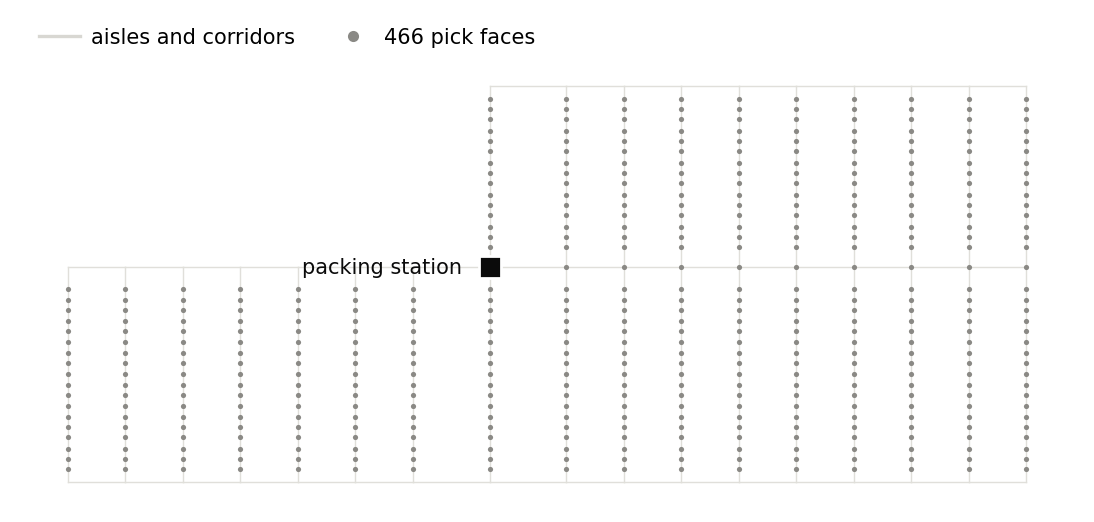

In [34]:
fig, ax = plt.subplots(figsize=(6.8, 3.0))
draw_network(ax)
pts = [T(p) for p in faces]
ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=3.5, color=INK3,
           zorder=2, linewidths=0)
dx, dy = T(DEPOT)
ax.scatter([dx], [dy], s=60, marker='s', color=INK,
           edgecolor='white', linewidth=1, zorder=5)
ax.annotate('packing station', (dx, dy), textcoords='offset points', xytext=(-10, 0),
            fontsize=7.5, color=INK, ha='right', va='center')
ax.legend(handles=[
    Line2D([], [], color='#d8d7d2', lw=1.2, label='aisles and corridors'),
    Line2D([], [], color=INK3, marker='o', ls='', ms=3, label=f'{len(faces)} pick faces'),
], loc='lower left', bbox_to_anchor=(0, 1.0), ncol=2, handletextpad=0.5,
   columnspacing=1.8)
fig.savefig(f'{FIG_DIR}/fig1_floor.png')
plt.show()

### 8.3 Figure 2 - one wave, before and after

The largest wave in the held-out set, walked in the order the company listed it and in the
order simulated annealing found. Both panels are drawn to the same scale and cropped to the
part of the floor the wave uses, so the two shapes can be compared directly.

The saving is not made by finding shortcuts — there are none, the paths between stops are
already the shortest the aisles allow. It is made by removing repeated traversals: the listed
order enters and leaves the same region several times, and reordering the stops folds those
crossings into one pass.

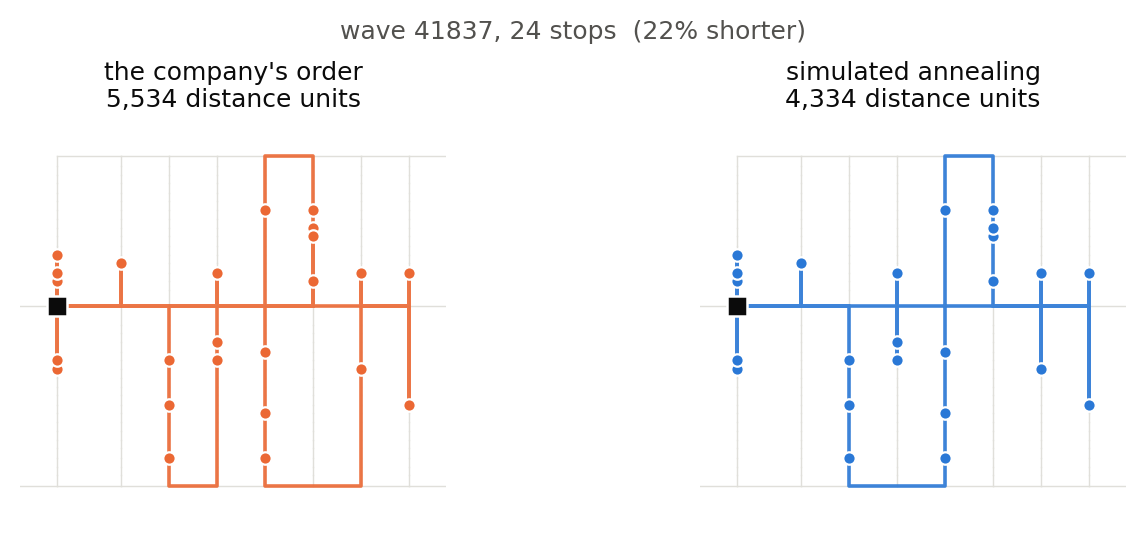

In [35]:
demo = holdout.sort_values('n_stops', ascending=False).iloc[0]
demo_route = waves.loc[demo.wave].route
sa_route, sa_cost = solve_sa(demo_route)
listed_cost = route_length(demo_route)

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6), constrained_layout=True)
spans = []
for ax, order, colour, label, cost in [
        (axes[0], demo_route, ORANGE, "the company's order", listed_cost),
        (axes[1], sa_route, BLUE, 'simulated annealing', sa_cost)]:
    draw_network(ax)
    spans.append(draw_route(ax, order, colour))
    ax.set_title(f'{label}\n{cost:,.0f} distance units', color=INK, pad=4)

pad = 70
xlo = min(min(s[0]) for s in spans) - pad
xhi = max(max(s[0]) for s in spans) + pad
ylo = min(min(s[1]) for s in spans) - pad
yhi = max(max(s[1]) for s in spans) + pad
for ax in axes:
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)

fig.suptitle(f'wave {demo.wave}, {int(demo.n_stops)} stops  '
             f'({1 - sa_cost / listed_cost:.0%} shorter)', fontsize=9, color=INK2)
fig.savefig(f'{FIG_DIR}/fig2_before_after.png')
plt.show()

### 8.4 Figure 3 - how the two searches converge

Best route found so far against evaluations spent, averaged over 20 seeds on the same wave as
Figure 2. The shaded band is the range across those seeds. The horizontal line is the
company's order, for reference.

The two curves have different shapes, and the shapes explain the results. Simulated annealing
improves steeply from the start and has essentially finished by about 1,000 evaluations; the
remaining 9,000 buy almost nothing. The genetic algorithm starts slower because its first 100
evaluations are spent building a random population, improves gradually as the population
converges, and is still improving when the budget runs out.

The narrowing of the shaded bands says the same thing about reliability that Section 6's
standard deviations did: by the end of the budget the annealing runs have all reached
approximately the same route, while the genetic algorithm's runs are still spread apart.

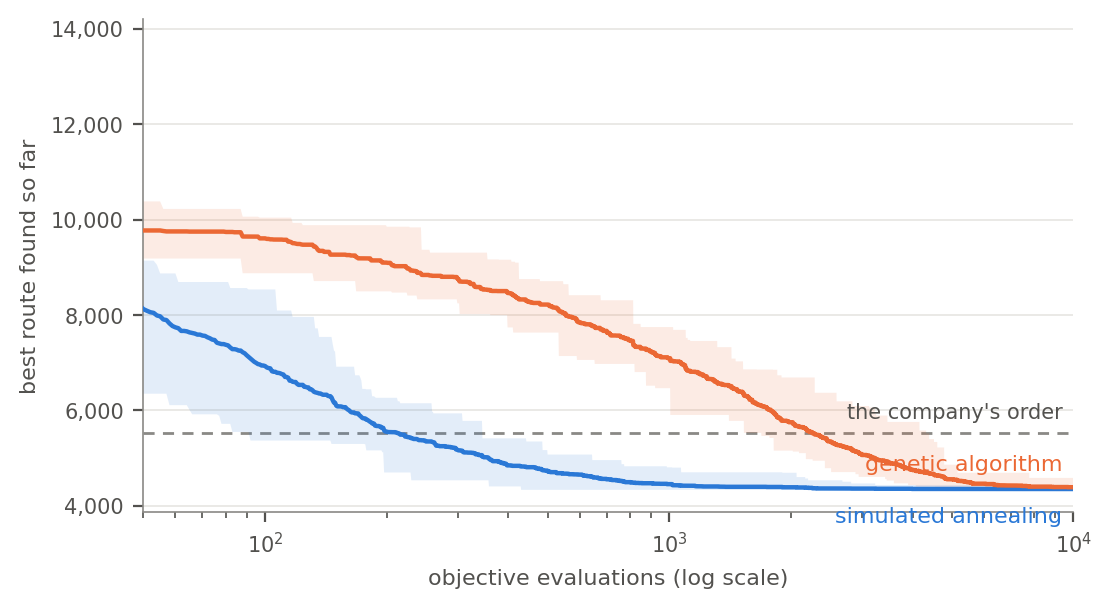

In [36]:
TRACE_SEEDS = 20
traces = {}
for name in ('simulated annealing', 'genetic algorithm'):
    runs = []
    for s in range(TRACE_SEEDS):
        obj = TracedObjective(route_length)
        if name.startswith('sim'):
            simulated_annealing(demo_route, obj, two_opt_neighbour, fast_cooling, BUDGET, s)
        else:
            genetic_algorithm(demo_route, obj, inversion_mutation, BUDGET,
                              population_size=100, seed=s)
        runs.append(obj.trace[:BUDGET])
    traces[name] = np.array(runs)

fig, ax = plt.subplots(figsize=(6.0, 3.2))
x = np.arange(1, BUDGET + 1)
ax.axhline(listed_cost, color=INK3, lw=1, ls=(0, (4, 3)), zorder=1)
ax.annotate("the company's order", (BUDGET, listed_cost), textcoords='offset points',
            xytext=(-4, 5), ha='right', fontsize=7.5, color=INK2)
for name, colour, dy in [('simulated annealing', BLUE, -12),
                         ('genetic algorithm', ORANGE, 6)]:
    runs = traces[name]
    ax.fill_between(x, runs.min(0), runs.max(0), color=colour, alpha=0.13,
                    linewidth=0, zorder=2)
    ax.plot(x, runs.mean(0), color=colour, lw=1.6, zorder=3)
    ax.annotate(name, (BUDGET, runs.mean(0)[-1]), textcoords='offset points',
                xytext=(-4, dy), ha='right', fontsize=8, color=colour)
ax.set_xscale('log')
ax.set_xlim(50, BUDGET)
ax.set_xlabel('objective evaluations (log scale)')
ax.set_ylabel('best route found so far')
ax.yaxis.set_major_formatter(lambda v, p: f'{v:,.0f}')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
fig.savefig(f'{FIG_DIR}/fig3_convergence.png')
plt.show()

### 8.5 Figure 4 - saving by wave size

The held-out saving for all three methods, broken down by how many stops the wave has.

Every method saves more on larger waves, which the geometry predicts: more stops means more
possible orderings and more slack for a poor one to waste. The gap between nearest neighbour
and the two AI techniques is roughly constant in percentage points, so the searching is not
merely repairing greedy mistakes that only appear on large waves.

The two AI techniques are level on the smallest waves, where both find the optimum, and
separate as the waves grow. That is the expected shape: the harder the instance, the more the
quality of the search matters.

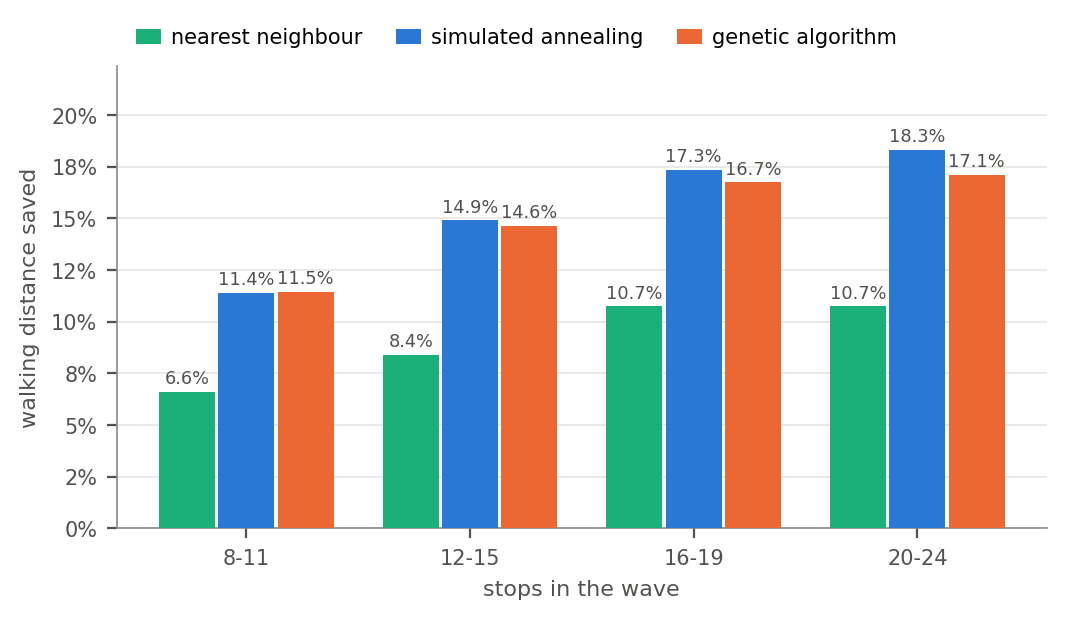

In [37]:
by_band = holdout.groupby('band', observed=True)[['nn_save', 'SA_save', 'GA_save']].mean()
pos = np.arange(len(by_band))
width = 0.25

fig, ax = plt.subplots(figsize=(6.0, 3.0))
for k, (col, name, colour) in enumerate([('nn_save', 'nearest neighbour', AQUA),
                                         ('SA_save', 'simulated annealing', BLUE),
                                         ('GA_save', 'genetic algorithm', ORANGE)]):
    xs = pos + (k - 1) * (width + 0.015)
    ax.bar(xs, by_band[col], width, color=colour, label=name, zorder=3)
    for xi, v in zip(xs, by_band[col]):
        ax.annotate(f'{v:.1%}', (xi, v), textcoords='offset points', xytext=(0, 3),
                    ha='center', fontsize=6.4, color=INK2)
ax.set_xticks(pos, list(by_band.index))
ax.set_xlabel('stops in the wave')
ax.set_ylabel('walking distance saved')
ax.yaxis.set_major_formatter(lambda v, p: f'{v:.0%}')
ax.set_ylim(0, by_band.values.max() * 1.22)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=3, columnspacing=1.6,
          handlelength=1.2, handletextpad=0.5)
fig.savefig(f'{FIG_DIR}/fig4_by_size.png')
plt.show()

### 8.6 Figure 5 - how the budget could be cut

Section 4.4 asked which cooling schedule to use. This asks the related question of the two
finished techniques: if the evaluation budget had to be smaller, how much worse would each get?

Because the traced runs record the best route at every evaluation, this needs no extra
experiments — the answer for every budget comes out of the same 10,000-evaluation runs.

The two techniques answer very differently. Simulated annealing is already saving 13% after
500 evaluations and is within half a percentage point of its final result by 2,500. The genetic
algorithm needs the full budget: at 2,500 evaluations it is barely better than doing nothing,
and below that it is worse than the company's existing order, because a population that has
not yet converged is still mostly random routes.

This matters beyond this dataset. The two techniques are close at 10,000 evaluations, but that
particular budget was chosen in Section 4 for reasons unrelated to this comparison. At a
quarter of it, the difference between them is the difference between a working system and one
that makes things worse.

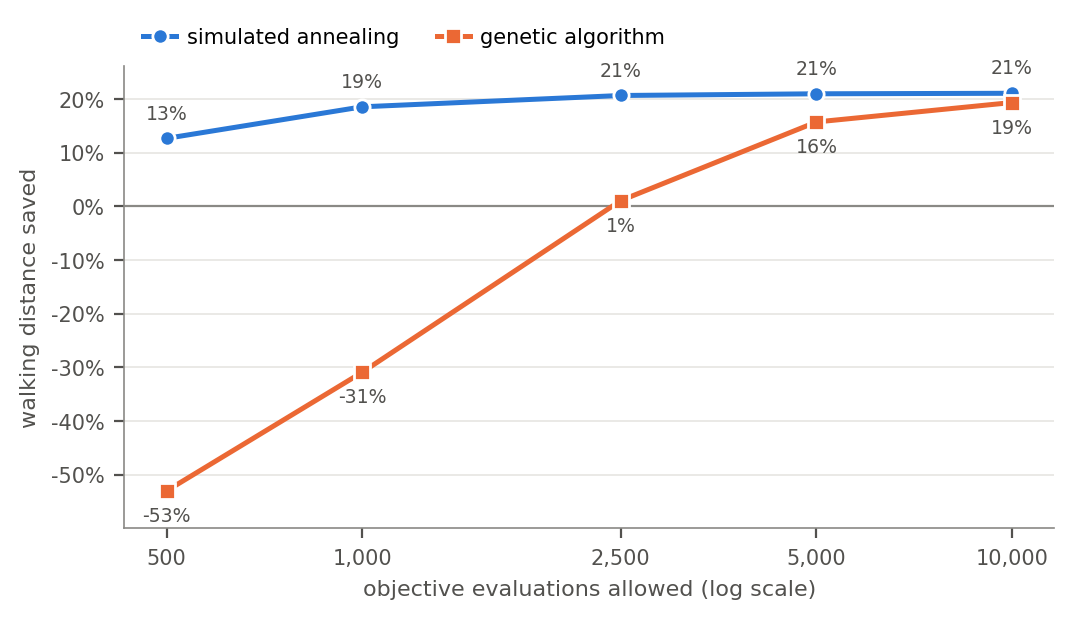

budget    500 : SA  12.7%   GA -53.0%
budget  1,000 : SA  18.6%   GA -30.9%
budget  2,500 : SA  20.7%   GA   1.1%
budget  5,000 : SA  21.0%   GA  15.7%
budget 10,000 : SA  21.1%   GA  19.4%


In [38]:
BUDGET_POINTS = [500, 1000, 2500, 5000, 10000]
TRACE_WAVES, TRACE_SEEDS_5 = 8, 10
sample = holdout.nlargest(TRACE_WAVES, 'n_stops')


def trace_runs(route, technique, seeds):
    out = []
    for s in range(seeds):
        obj = TracedObjective(route_length)
        if technique == 'SA':
            simulated_annealing(route, obj, two_opt_neighbour, fast_cooling, BUDGET, s)
        else:
            genetic_algorithm(route, obj, inversion_mutation, BUDGET,
                              population_size=100, seed=s)
        out.append(obj.trace[:BUDGET])
    return np.array(out)


curve, listed_total = {'SA': [], 'GA': []}, 0.0
for wave_id in sample.wave:
    r = waves.loc[wave_id].route
    listed_total += route_length(r)
    for key in ('SA', 'GA'):
        curve[key].append(trace_runs(r, key, TRACE_SEEDS_5).mean(0))

saving = {k: [1 - sum(c[b - 1] for c in curve[k]) / listed_total for b in BUDGET_POINTS]
          for k in curve}

fig, ax = plt.subplots(figsize=(6.0, 3.0))
for key, name, colour, marker in [('SA', 'simulated annealing', BLUE, 'o'),
                                  ('GA', 'genetic algorithm', ORANGE, 's')]:
    ax.plot(BUDGET_POINTS, saving[key], color=colour, lw=1.8, marker=marker,
            ms=5.5, mec='white', mew=1, zorder=3, label=name)
    for b, v in zip(BUDGET_POINTS, saving[key]):
        ax.annotate(f'{v:.0%}', (b, v), textcoords='offset points',
                    xytext=(0, 7 if key == 'SA' else -11),
                    ha='center', fontsize=6.8, color=INK2)
ax.axhline(0, color=INK3, lw=0.8, zorder=1)
ax.set_xscale('log')
ax.set_xticks(BUDGET_POINTS, [f'{b:,}' for b in BUDGET_POINTS])
ax.minorticks_off()
ax.set_xlabel('objective evaluations allowed (log scale)')
ax.set_ylabel('walking distance saved')
ax.yaxis.set_major_formatter(lambda v, p: f'{v:.0%}')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
lo = min(min(saving['SA']), min(saving['GA']))
hi = max(max(saving['SA']), max(saving['GA']))
ax.set_ylim(lo - 0.07, hi + 0.05)
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=2, columnspacing=1.8,
          handlelength=1.6, handletextpad=0.5)
fig.savefig(f'{FIG_DIR}/fig5_budget.png')
plt.show()

for b, sa_v, ga_v in zip(BUDGET_POINTS, saving['SA'], saving['GA']):
    print(f'budget {b:>6,} : SA {sa_v:6.1%}   GA {ga_v:6.1%}')

### 8.7 Figure 6 - what each method costs

Every method on one pair of axes: what it saves against what it costs to run. The dashed line
joins them in order of cost.

Nearest neighbour is the honest bar to clear. It saves 10% of the walking for a hundredth of a
millisecond, so any method that costs more has to justify itself against that, not against the
company's order.

Simulated annealing does justify itself: six and a half more points of saving, and it fails far
less often — a longer route than the company's on 8 waves against nearest neighbour's 307. The
genetic algorithm sits below and to the right of it, saving less for twice the compute, which
is the definition of a dominated option. There is no budget or scale at which it is the right
choice on this problem.

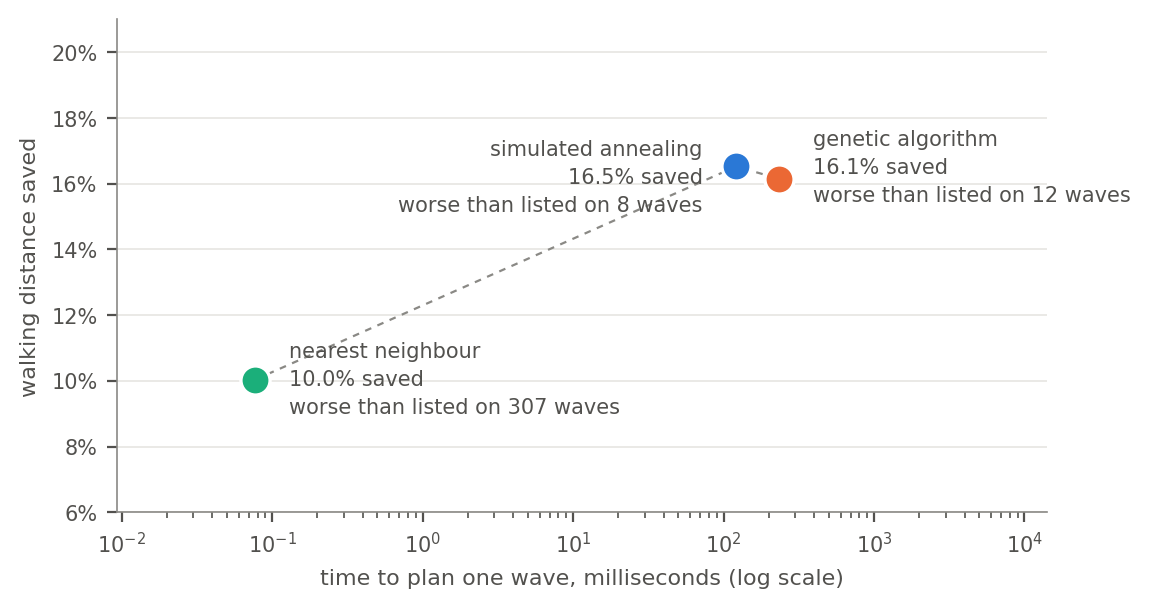

In [39]:
methods = [('nearest neighbour', AQUA, holdout.nn_sec.mean() * 1000,
            1 - holdout.nn.sum() / holdout.listed.sum(), (holdout.nn_save < 0).sum()),
           ('simulated annealing', BLUE, holdout.SA_sec.mean() * 1000,
            1 - holdout.SA.sum() / holdout.listed.sum(), (holdout.SA_save < 0).sum()),
           ('genetic algorithm', ORANGE, holdout.GA_sec.mean() * 1000,
            1 - holdout.GA.sum() / holdout.listed.sum(), (holdout.GA_save < 0).sum())]
PLACEMENT = [('left', (12, 0)), ('right', (-12, -4)), ('left', (12, 4))]

fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot([m[2] for m in methods], [m[3] for m in methods], color=INK3, lw=0.8,
        ls=(0, (3, 3)), zorder=2)
for (name, colour, ms_, save, bad), (ha, offset) in zip(methods, PLACEMENT):
    ax.scatter([ms_], [save], s=110, color=colour, edgecolor='white', linewidth=1.2,
               zorder=4)
    ax.annotate(f'{name}\n{save:.1%} saved\nworse than listed on {bad} waves',
                (ms_, save), textcoords='offset points', xytext=offset,
                ha=ha, va='center', fontsize=7.5, color=INK2, linespacing=1.5)
ax.set_xscale('log')
ax.set_xlabel('time to plan one wave, milliseconds (log scale)')
ax.set_ylabel('walking distance saved')
ax.yaxis.set_major_formatter(lambda v, p: f'{v:.0%}')
ax.set_ylim(0.06, 0.21)
ax.set_xlim(holdout.nn_sec.mean() * 120, holdout.GA_sec.mean() * 60000)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
fig.savefig(f'{FIG_DIR}/fig6_cost.png')
plt.show()

## 9. Recommendation and conclusions

### 9.1 Everything in one table

The table below is the result of the project, drawn entirely from the held-out waves. It is
also the table the report quotes, so the report and the notebook cannot drift apart.

Three columns matter and they say different things. The overall saving is what the warehouse
would experience across the season, weighted towards long waves because they contribute more
walking. The per-wave saving treats every wave equally. The count of waves made worse is the
column a warehouse manager would look at first, because a method that is usually better and
occasionally much worse is harder to trust than its average suggests.

In [40]:
for c in ('nn', 'SA', 'GA'):
    holdout[f'{c}_save'] = 1 - holdout[c] / holdout.listed

summary = pd.DataFrame({
    'saved overall': [1 - holdout[c].sum() / holdout.listed.sum() for c in ('nn', 'SA', 'GA')],
    'saved per wave': [holdout[f'{c}_save'].mean() for c in ('nn', 'SA', 'GA')],
    'worse than listed': [(holdout[f'{c}_save'] < 0).sum() for c in ('nn', 'SA', 'GA')],
    'ms per wave': [holdout[f'{c}_sec'].mean() * 1000 for c in ('nn', 'SA', 'GA')],
}, index=['nearest neighbour', 'simulated annealing', 'genetic algorithm'])

shown = pd.DataFrame({
    'saved overall': summary['saved overall'].map('{:.1%}'.format),
    'saved per wave': summary['saved per wave'].map('{:.1%}'.format),
    'worse than listed': summary['worse than listed'].map(
        lambda v: f'{v:,} of {len(holdout):,}'),
    'ms per wave': summary['ms per wave'].map('{:.2f}'.format),
})
print(f'held-out evaluation, {len(holdout):,} waves never used in tuning')
print(shown.to_string())

differ = holdout[holdout.SA != holdout.GA]
stat_out, p_out = wilcoxon(differ.SA, differ.GA)
stat_tune, p_tune = wilcoxon(results.SA_mean, results.GA_mean)

print('\nsimulated annealing against the genetic algorithm')
print(f'  tuning waves   : mean gap {results.SA_gap.mean():.2%} against '
      f'{results.GA_gap.mean():.2%}, Wilcoxon p={p_tune:.4f}')
print(f'  held-out waves : shorter on {(holdout.SA < holdout.GA).sum():,}, '
      f'longer on {(holdout.GA < holdout.SA).sum():,}, Wilcoxon p={p_out:.3g}')
print(f'  cost           : {holdout.SA_sec.mean() / holdout.GA_sec.mean():.2f} times the '
      f"genetic algorithm's running time at the same evaluation budget")

held-out evaluation, 2,225 waves never used in tuning
                    saved overall saved per wave worse than listed ms per wave
nearest neighbour           10.0%           8.8%      307 of 2,225        0.08
simulated annealing         16.5%          15.0%        8 of 2,225      121.23
genetic algorithm           16.1%          14.6%       12 of 2,225      235.19

simulated annealing against the genetic algorithm
  tuning waves   : mean gap 0.31% against 1.21%, Wilcoxon p=0.0001
  held-out waves : shorter on 496, longer on 180, Wilcoxon p=7.27e-27
  cost           : 0.52 times the genetic algorithm's running time at the same evaluation budget


### 9.2 Recommendation

**Simulated annealing**, with the 2-opt neighbourhood and fast cooling.

The recommendation rests on three separate arguments, and it is worth separating them because
they would not all survive a change of circumstances.

**Quality.** Simulated annealing produces shorter routes on both the tuning waves and the
held-out waves, and the difference is significant in both. The margin is small in absolute
terms — 16.5% against 16.1% of walking saved - and it is level on the smallest waves, where
both techniques reach the optimum. It widens as the waves grow, which is where it matters,
because long waves account for a disproportionate share of the total walking.

**Reliability.** This is the stronger argument and it does not appear in the headline
percentages. Across 30 seeds on every one of the 32 tuning waves, both techniques eventually
find the same best route. What separates them is how often they find it: on the largest waves
the annealing runs vary by around 15 distance units and the genetic algorithm's by over 90. A
warehouse runs each wave once, so what matters is the quality of a single run, not the best of
thirty. On the held-out set simulated annealing produced a worse-than-listed route on 8 waves
of 2,225; the genetic algorithm on 12.

**Cost.** At an identical evaluation budget simulated annealing takes half the wall-clock time,
because the genetic algorithm sorts its population, runs tournaments and performs crossovers
around every evaluation, and none of that work is visible to the evaluation counter. It also
needs far less of the budget: it is within half a percentage point of its final answer by 2,500
evaluations, where the genetic algorithm is still worse than doing nothing.

There is no scenario in this dataset where the genetic algorithm is the better choice. It is
slower, slightly worse, less consistent, and degrades much faster when the budget is cut.

**A second recommendation that is not about the two techniques.** Nearest neighbour captures
10.0 of the 16.5 percentage points in a fraction of a millisecond. Any warehouse considering
this work should implement that first: it is twenty lines of code and delivers nearly two
thirds of the benefit. Simulated annealing is worth adding on top of it, but the case for doing
so is the 307 waves nearest neighbour makes worse, not the six extra percentage points.

### 9.3 What these numbers do not say

**The units are inferred.** The dataset gives coordinates without stating what they measure.
Comparing the longest walk in the building against the published floor area suggests
decimetres, but this is not documented, so every result here is reported as a percentage.
Nothing in this notebook supports a claim about metres walked or minutes saved.

**One warehouse, one layout, one depot.** The packing station's position was read from the
layout figure published with the dataset, not from the data itself. Moving it would change
every distance in the matrix. Whether the same recommendation holds in a rectangular warehouse
with more cross aisles is untested.

**The waves are taken as given.** Which items are grouped into a wave is fixed by the company's
own batching, and this project only reorders the stops within a wave it is handed. Better
batching may well be worth more than better routing, and the two interact: a wave whose items
are already clustered leaves less for any router to save.

**The movement model is static.** It assumes one picker walking the shortest aisle path, with
no congestion, no time spent picking, no interaction between the 22 pickers working
simultaneously, and no vertical travel between the four rack levels. Real picking time is not
proportional to walking distance.

**One evaluation budget.** The comparison is run at 10,000 evaluations, a figure chosen in
Section 4.5 for reasons unrelated to the comparison. Figure 5 shows the ranking is stable
across budgets, but the size of the margin is not.

**Two sampling flaws were found in this project's own experiments.** Section 4.3 compared
cooling schedules on waves too easy to distinguish between them, and Section 6.1 selected its
sample with `.head()`, which took the earliest waves rather than representative ones. Both were
caught only by re-testing on differently chosen data. There is no reason to assume a third does
not remain.

### 9.4 What would change the answer

**A better move operator, not a better metaheuristic.** This is the clearest finding in the
project and it cuts across both techniques. Simulated annealing improved far more from
replacing swap with 2-opt than from any cooling schedule, and the genetic algorithm improved
far more from replacing swap mutation with inversion than from any population size. Both
improvements are the same change: replacing a move that exchanges two stops with one that
reverses a segment, which is what actually removes a crossing from a route. The obvious next
step is a memetic algorithm - a genetic algorithm whose children are improved by 2-opt local
search before being evaluated - which would test whether the population is adding anything once
the move operator is good.

**Joint batching and routing.** Optimising which items share a wave, and the order within it,
as one problem rather than two.

**Validation against the dataset's own timestamps.** The picking waves carry start and end
times. Regressing measured duration on computed walking distance would test the assumption that
distance is a good proxy for time, and would let the saving be expressed in hours rather than
percentages.

**A second layout.** Repeating the held-out evaluation on a warehouse with a different aisle
structure would establish whether the recommendation is about simulated annealing or about this
building.